**Instalar las herramientas**:

Instalar la librería de Roboflow y la de CLIP:

In [1]:
!pip install roboflow open-clip-torch torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [2]:
# Borra la carpeta donde se descargaron los datos anteriormente
!rm -rf datasets

extraer los datos del .zip

In [3]:
import zipfile
import os

# Reemplaza 'tu_archivo.zip' por el nombre real de tu archivo
zip_path = '/content/clipv7.v1-clipv7.folder.zip'
extract_path = '/content/dataset_final'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Descompresión completada en:", extract_path)

Descompresión completada en: /content/dataset_final


Inicialización del modelo CLIP

In [4]:
import open_clip
from PIL import Image
import os

# 0. Cargar el modelo CLIP
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
tokenizer = open_clip.get_tokenizer('ViT-B-32')

# Obtener los nombres de las clases (basado en la estructura de carpetas del dataset)
# Asegúrate de que 'dataset' esté definido y sea accesible aquí. Si no, necesitarás ejecutar la celda de descarga de Roboflow primero.
class_names = sorted(os.listdir(os.path.join(extract_path, 'train'))) # Corrección: Usar extract_path en lugar de dataset_final.location
# Definimos manualmente las etiquetas que queremos que CLIP compare:
#class_names = ['assembled_parts', 'circular_female_part', 'circular_male_part', 'disassembled_parts', "square_male_part", "TRIANGULAR_MALE_PART", "TRIANGULAR_FEMALE_PART"] #esto no estaba
print(f"Clases detectadas: {class_names}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Clases detectadas: ['part_circular_female_white', 'part_circular_female_yellow', 'part_circular_male_white', 'part_circular_male_yellow', 'part_circular_white_assembled', 'part_circular_white_dissasembled', 'part_circular_yellow_assembled', 'part_circular_yellow_dissasembled', 'part_square_female_white', 'part_square_female_yellow', 'part_square_male_white', 'part_square_male_yellow', 'part_square_white_assembled', 'part_square_white_dissasembled', 'part_square_yellow_assembled', 'part_square_yellow_dissasembled', 'part_squarerounded_female_white', 'part_squarerounded_female_yellow', 'part_squarerounded_male_white', 'part_squarerounded_male_yellow', 'part_squarerounded_white_assembled', 'part_squarerounded_white_dissasembled', 'part_squarerounded_yellow_assembled', 'part_squarerounded_yellow_dissasembled', 'scene_without_pcs']


definicion del dataset


In [5]:
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class RoboflowCLIPDataset(Dataset):
    def __init__(self, root_dir, transform, tokenizer, class_names):
        """
        Constructor del Dataset. Escanea las carpetas, limpia las etiquetas
        para lenguaje natural y estructura las rutas de los archivos.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.tokenizer = tokenizer
        self.class_names = class_names

        # Listas para almacenar la información de cada muestra en el dataset
        self.image_paths = []  # Rutas a los archivos de imagen
        self.labels = []       # Índices numéricos de las clases (0, 1, 2...)
        self.captions = []     # Frases en lenguaje común (ej. "part circular white")

        # Recorremos cada una de las carpetas de clase especificadas
        for idx, label in enumerate(class_names):
            class_path = os.path.join(root_dir, label)

            # Verificamos que la ruta corresponda a un directorio válido
            if os.path.isdir(class_path):

                # Reemplazamos guiones bajos por espacios y pasamos a minúsculas.
                # Convierte "part_circular_assembled" en "part circular assembled"
                clean_caption = label.replace("_", " ").lower()

                # Iteramos sobre todas las imágenes dentro de la carpeta de la clase actual
                for img_name in os.listdir(class_path):
                    # Construimos y guardamos la ruta completa de la imagen
                    self.image_paths.append(os.path.join(class_path, img_name))

                    # Guardamos el índice numérico de la clase para cálculo de métricas/pérdida
                    self.labels.append(idx)

                    # Guardamos la descripción limpia que se alineará con el codificador de texto
                    self.captions.append(clean_caption)

    def __len__(self):
        """
        Devuelve la cantidad total de imágenes cargadas en el dataset.
        Permite al DataLoader saber cuántas muestras componen una época.
        """
        return len(self.image_paths)

    def __getitem__(self, idx):

        # 1. Procesamiento Visual
        image = self.transform(Image.open(self.image_paths[idx]))

        # 2. Construcción de la Descripción (Prompt)
        label_text = f"a photo of a {self.captions[idx]}"

        # 3. Procesamiento de Texto (Tokenización)
        # Convierte el string de texto en un tensor de tokens de tamaño fijo.
        # Se extrae el primer elemento ([0]) para obtener el tensor directo que requiere el modelo.
        tokenized_text = self.tokenizer([label_text])[0]

        return image, tokenized_text, self.labels[idx]

entrenamiento mejorado

In [6]:
import os
import math
import torch
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, random_split


# Configura el dispositivo: usa GPU (cuda) si está disponible para acelerar el proceso
device        = "cuda" if torch.cuda.is_available() else "cpu"
num_epochs    = 2
batch_size    = 32
lr            = 1e-5      # Tasa de aprendizaje baja (Fine-tuning) para no destruir pesos preentrenados
weight_decay  = 0.05    # Penalización a pesos grandes para evitar sobreentrenamiento (overfitting)
warmup_steps  = 500     # Pasos iniciales donde el LR sube linealmente para dar estabilidad
max_grad_norm = 1.0     # Umbral máximo para el recorte de gradientes (evita explosión de gradientes)
patience      = 15
min_delta     = 5e-4    # Mejora mínima requerida en la métrica para considerarse avance
val_split     = 0.15    # Porcentaje del dataset destinado a pruebas (15%)

print(f"Dispositivo de entrenamiento activo: {device}")



# Ruta donde se encuentran las carpetas de imágenes
train_path = "/content/dataset_final/train"

# Instanciamos el dataset personalizado (carga rutas, mapea clases y limpia etiquetas)
full_dataset = RoboflowCLIPDataset(train_path, preprocess, tokenizer, class_names)

# Calculamos el tamaño exacto para entrenamiento y validación
val_size   = int(val_split * len(full_dataset))
train_size = len(full_dataset) - val_size


train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Configuración de DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=4, pin_memory=True
)

# Cálculo de la cantidad de pasos
steps_per_epoch = len(train_loader)
total_steps     = num_epochs * steps_per_epoch

print(f"Muestras de Train: {train_size} imágenes | Muestras de Val: {val_size} imágenes")
print(f"Pasos (steps) por época: {steps_per_epoch} | Pasos totales programados: {total_steps}")


# Limpiamos las etiquetas quitando guiones bajos y pasando a minúsculas
clean_class_names = [name.replace("_", " ").lower() for name in class_names]
# Tokenizamos
all_class_texts = tokenizer(clean_class_names).to(device)



model.to(device)

# División de parámetros: aplicamos Weight Decay a pesos generales
no_decay = ["logit_scale"]
param_groups = [
    {
        "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay) and p.requires_grad],
        "weight_decay": weight_decay
    },
    {
        "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay) and p.requires_grad],
        "weight_decay": 0.0
    },
]

# Inicialización del optimizador AdamW
optimizer = torch.optim.AdamW(param_groups, lr=lr)

# Definición del Scheduler: Subida gradual (Warm-up) seguido de caída (Cosine Decay)
def lr_lambda(current_step):
    if current_step < warmup_steps:
        return current_step / max(1, warmup_steps)
    progress = (current_step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Criterios de pérdida
loss_img = torch.nn.CrossEntropyLoss()
loss_txt = torch.nn.CrossEntropyLoss()

# Escalador para habilitar Precisión Mixta
scaler = GradScaler()


def clip_loss(images, texts):

    # Extracción de características vectoriales de ambos componentes
    image_features = model.encode_image(images)
    text_features  = model.encode_text(texts)

    # Normalización de vectores
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    text_features  = text_features  / text_features.norm(dim=-1, keepdim=True)

    logit_scale      = model.logit_scale.exp().clamp(max=100)

    # Cálculo de similitudes
    logits_per_image = logit_scale * image_features @ text_features.T
    logits_per_text  = logit_scale * text_features  @ image_features.T


    ground_truth = torch.arange(len(images), dtype=torch.long, device=device)

    # Pérdida final: Promedio del error desde la perspectiva de imágenes y desde textos
    loss = (loss_img(logits_per_image, ground_truth) + loss_txt(logits_per_text, ground_truth)) / 2
    return loss


def evaluate_global_accuracy(model, loader, all_texts, device):
    """
    Mide la precisión global (Top-1 y Top-5) evaluando las imágenes contra todas las clases.
    """
    model.eval()  # Modo de evaluación (desactiva Dropout/BatchNorm si existieran)
    correct_1 = 0
    correct_5 = 0
    total = 0

    # Pre-calculo de los embeddings de todas las clases disponibles
    with torch.no_grad():
        with autocast():
            all_text_features = model.encode_text(all_texts)
            all_text_features = all_text_features / all_text_features.norm(dim=-1, keepdim=True)

    with torch.no_grad():
        for images, _, text_indices_labels in loader:
            images = images.to(device, non_blocking=True)
            targets = text_indices_labels.to(device).unsqueeze(1)

            with autocast():
                image_features = model.encode_image(images)
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)

                similarity = image_features @ all_text_features.T

            # Extracción de las top-k clases con mayor nivel de similitud
            max_k = min(5, similarity.size(-1))
            topk_indices = similarity.topk(max_k, dim=-1).indices

            # Sumatoria de aciertos para métricas
            correct_1 += (topk_indices[:, :1] == targets).any(dim=1).sum().item()
            correct_5 += (topk_indices == targets).any(dim=1).sum().item()
            total += len(images)

    return correct_1 / total, correct_5 / total

best_acc     = 0.0
patience_cnt = 0
history      = []

print(f"\nIniciando modelo — Máximo {num_epochs} épocas | Paciencia Early Stopping = {patience}\n")

for epoch in range(num_epochs):

    #FASE DE ENTRENAMIENTO
    model.train() # Activamos el modo de entrenamiento en la arquitectura
    total_train_loss = 0.0

    for images, text_tokens, _ in train_loader:
        images = images.to(device, non_blocking=True)
        text_tokens = text_tokens.to(device, non_blocking=True)

        optimizer.zero_grad()


        with autocast():
            loss = clip_loss(images, text_tokens)


        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm) # Recorte de gradientes extremos
        scaler.step(optimizer)
        scaler.update()
        scheduler.step() # Actualización de la tasa de aprendizaje según la curva coseno

        total_train_loss += loss.item()

    #FASE DE VALIDACIÓN
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for images, text_tokens, _ in val_loader:
            images = images.to(device, non_blocking=True)
            text_tokens = text_tokens.to(device, non_blocking=True)

            with autocast():
                loss = clip_loss(images, text_tokens)

            total_val_loss += loss.item()

    #PROCESAMIENTO DE MÉTRICAS Y MONITOREO DE DESEMPEÑO
    avg_train  = total_train_loss / len(train_loader) # Error promedio de entrenamiento
    avg_val    = total_val_loss   / len(val_loader)   # Error promedio de validación
    gap        = avg_val - avg_train                  # Brecha de generalización
    current_lr = scheduler.get_last_lr()[0]           # Tasa de aprendizaje actual

    # Obtención del rendimiento del modelo simulando entorno de producción real
    acc_top1, acc_top5 = evaluate_global_accuracy(model, val_loader, all_class_texts, device)

    # Diagnóstico del estado del modelo según la brecha de error (GAP)
    if   gap < 0.10: status = " OK"
    elif gap < 0.30: status = " vigilar"
    else:            status = " overfitting"

    # Impresión estructurada del progreso actual
    print(
        f"Época {epoch+1:3d}/{num_epochs} | "
        f"Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f} | "
        f"Gap: {gap:.4f} {status} | "
        f"Top-1 Acc: {acc_top1:.3f} | Top-5 Acc: {acc_top5:.3f} | "
        f"LR: {current_lr:.2e}"
    )

    # Almacenamiento de datos para posterior graficación de curvas
    history.append({
        "epoch":      epoch + 1,
        "train_loss": avg_train,
        "val_loss":   avg_val,
        "gap":        gap,
        "top1":       acc_top1,
        "top5":       acc_top5,
    })

    # CONTROLADOR DE GUARDADO Y EARLY STOPPING
    if acc_top1 > best_acc + min_delta:
        best_acc     = acc_top1
        patience_cnt = 0
        torch.save(model.state_dict(), "best_clip.pt")
        print(f"           └─ Récord superado. Guardando configuración (Top-1 Global: {best_acc:.3f})")
    else:
        patience_cnt += 1
        print(f"           └─ Sin mejoras significativas en Top-1 Global ({patience_cnt}/{patience})")
        if patience_cnt >= patience:
            print(f"\n[EARLY STOPPING] Criterio alcanzado en la época {epoch+1}. Deteniendo ejecución.")
            break


# Recargamos la versión óptima que haya sido guardada durante todo el entrenamiento
model.load_state_dict(torch.load("best_clip.pt"))
print(f"\nProceso finalizado con éxito. Máxima precisión real Top-1 alcanzada: {best_acc:.3f}")

# Despliegue en formato tabular de todo el historial recopilado
print(f"\n{'Época':>6} {'Train L':>8} {'Val L':>8} {'Gap':>8} {'Top-1':>7} {'Top-5':>7}")
for h in history:
    print(
        f"{h['epoch']:>6} {h['train_loss']:>8.4f} {h['val_loss']:>8.4f} "
        f"{h['gap']:>8.4f} {h['top1']:>7.3f} {h['top5']:>7.3f}"
    )

Dispositivo de entrenamiento activo: cuda
Muestras de Train: 9746 imágenes | Muestras de Val: 1719 imágenes
Pasos (steps) por época: 305 | Pasos totales programados: 610


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



Iniciando modelo — Máximo 2 épocas | Paciencia Early Stopping = 15



/tmp/ipykernel_566/60708473.py:98: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_566/60708473.py:181: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_566/60708473.py:190: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should cal

Época   1/2 | Train Loss: 1.5593 | Val Loss: 1.0860 | Gap: -0.4733  OK | Top-1 Acc: 0.827 | Top-5 Acc: 0.996 | LR: 6.10e-06
           └─ Récord superado. Guardando configuración (Top-1 Global: 0.827)
Época   2/2 | Train Loss: 0.8537 | Val Loss: 0.8394 | Gap: -0.0143  OK | Top-1 Acc: 0.947 | Top-5 Acc: 0.998 | LR: 0.00e+00
           └─ Récord superado. Guardando configuración (Top-1 Global: 0.947)

Proceso finalizado con éxito. Máxima precisión real Top-1 alcanzada: 0.947

 Época  Train L    Val L      Gap   Top-1   Top-5
     1   1.5593   1.0860  -0.4733   0.827   0.996
     2   0.8537   0.8394  -0.0143   0.947   0.998


generacion de graficas train

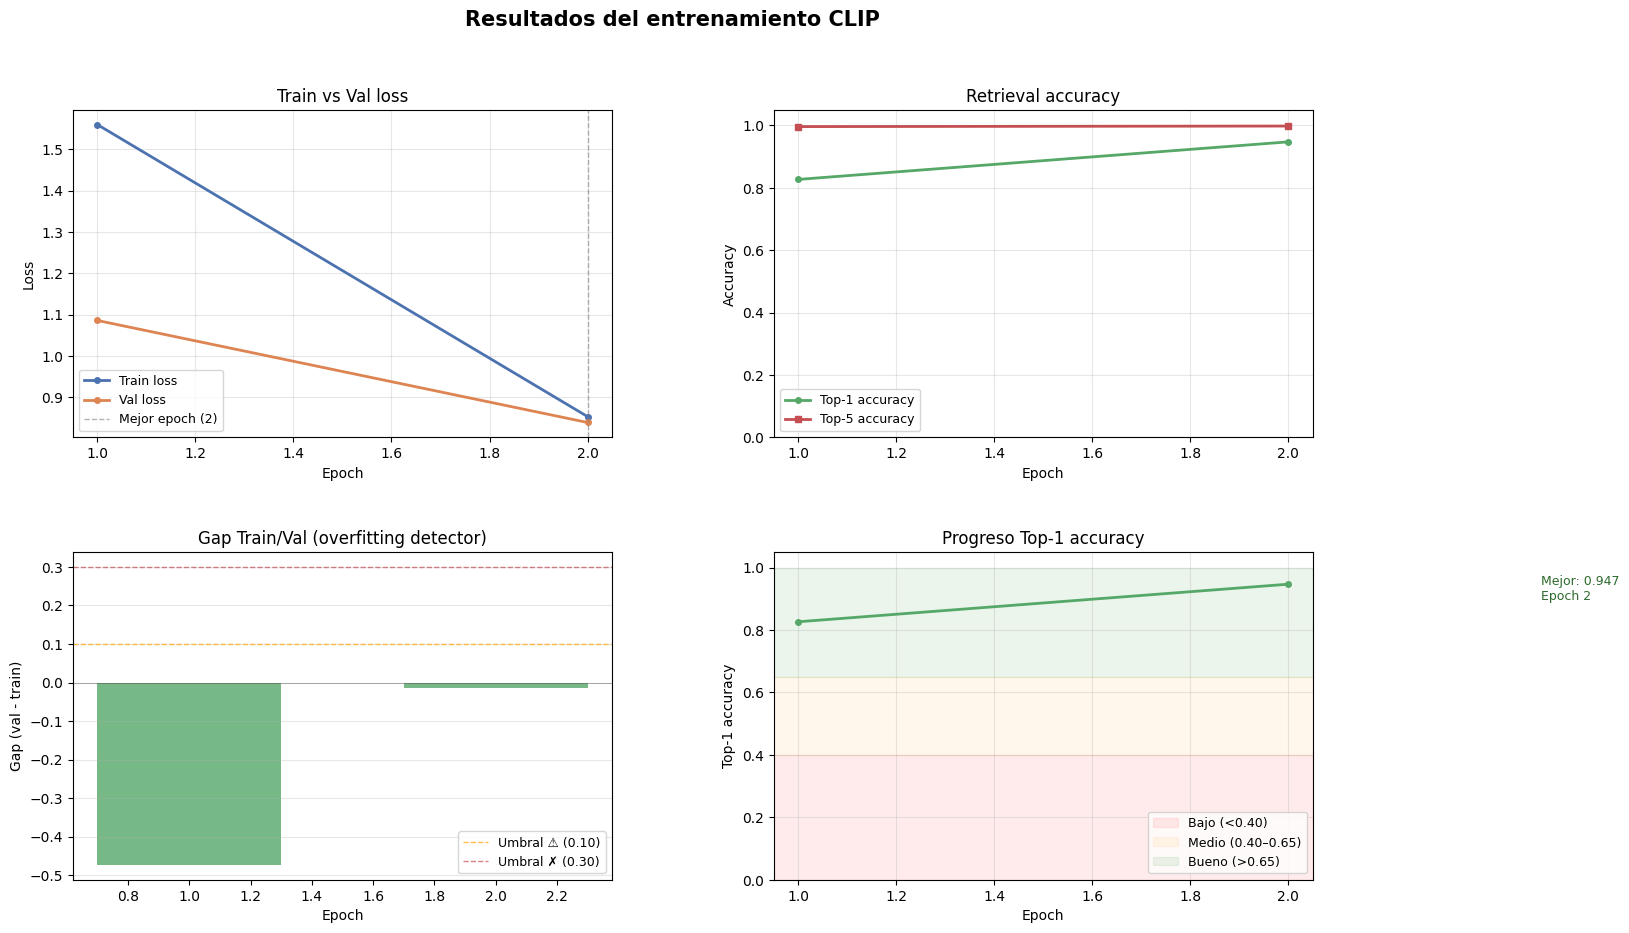

Gráfica guardada en training_curves.png


/tmp/ipykernel_566/2616699965.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_566/2616699965.py:113: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


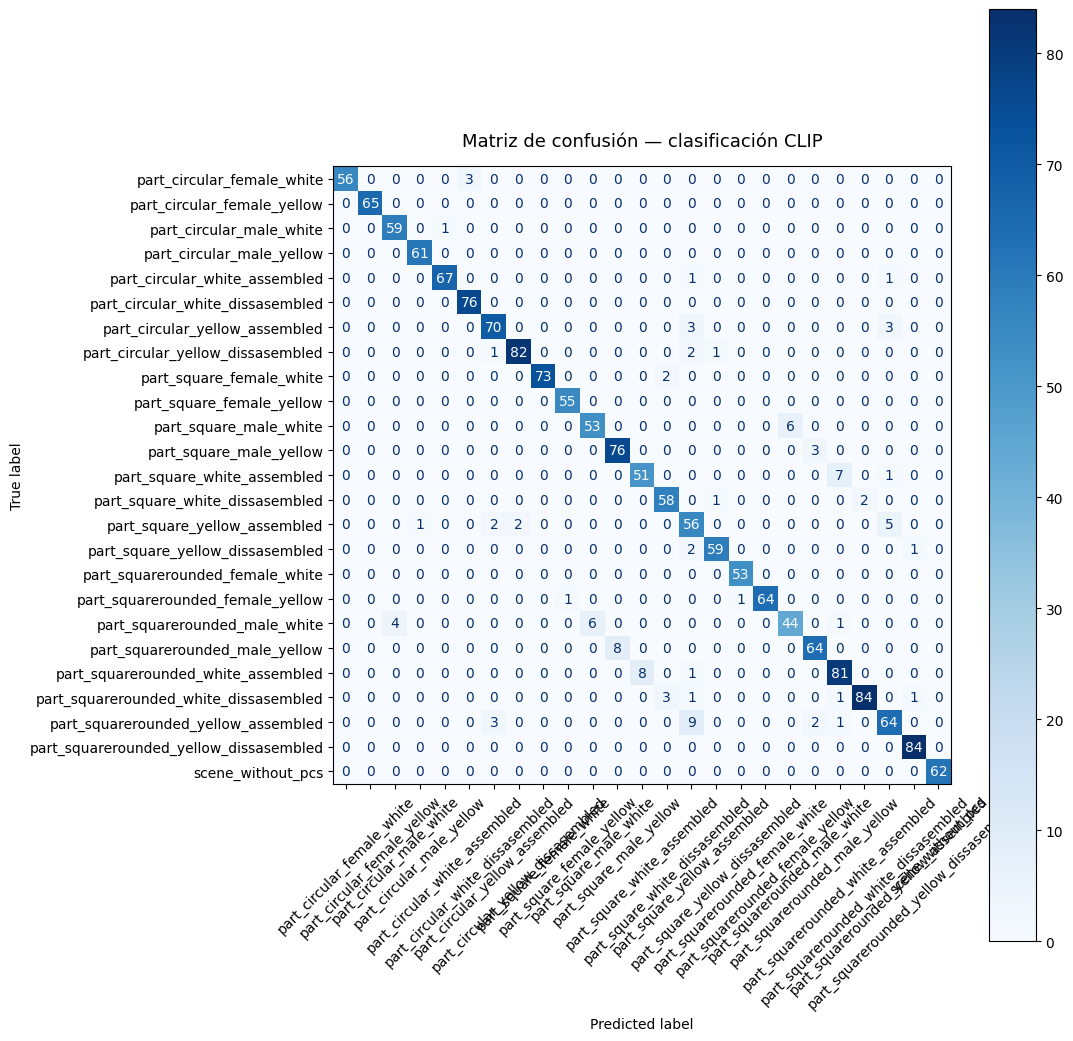

Matriz guardada en confusion_matrix.png

Precisión por clase:
Clase                      Correctas   Total   Accuracy
───────────────────────────────────────────────────────
part_circular_female_white         56      59     94.9%  ██████████████████
part_circular_female_yellow         65      65    100.0%  ████████████████████
part_circular_male_white          59      60     98.3%  ███████████████████
part_circular_male_yellow         61      61    100.0%  ████████████████████
part_circular_white_assembled         67      69     97.1%  ███████████████████
part_circular_white_dissasembled         76      76    100.0%  ████████████████████
part_circular_yellow_assembled         70      76     92.1%  ██████████████████
part_circular_yellow_dissasembled         82      86     95.3%  ███████████████████
part_square_female_white          73      75     97.3%  ███████████████████
part_square_female_yellow         55      55    100.0%  ████████████████████
part_square_male_white            53 

In [7]:
import torch
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.cuda.amp import autocast

#Función: graficar curvas de entrenamiento
def plot_training_curves(history):
    epochs     = [h["epoch"]      for h in history]
    train_loss = [h["train_loss"] for h in history]
    val_loss   = [h["val_loss"]   for h in history]
    top1       = [h["top1"]       for h in history]
    top5       = [h["top5"]       for h in history]
    gap        = [h["gap"]        for h in history]

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle("Resultados del entrenamiento CLIP", fontsize=15, fontweight="bold", y=0.98)
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

    #1. Train vs Val Loss
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, train_loss, "o-", color="#4C72B0", linewidth=2, markersize=4, label="Train loss")
    ax1.plot(epochs, val_loss,   "o-", color="#DD8452", linewidth=2, markersize=4, label="Val loss")
    best_epoch = history[np.argmin(val_loss)]["epoch"]
    ax1.axvline(best_epoch, color="gray", linestyle="--", linewidth=1, alpha=0.6, label=f"Mejor epoch ({best_epoch})")
    ax1.set_title("Train vs Val loss", fontsize=12)
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    #2. Top-1 y Top-5 Accuracy
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, top1, "o-", color="#55A868", linewidth=2, markersize=4, label="Top-1 accuracy")
    ax2.plot(epochs, top5, "s-", color="#C44E52", linewidth=2, markersize=4, label="Top-5 accuracy")
    ax2.set_title("Retrieval accuracy", fontsize=12)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0, 1.05)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    #3. Gap Train/Val
    ax3 = fig.add_subplot(gs[1, 0])
    colors = ["#55A868" if g < 0.10 else "#FFA500" if g < 0.30 else "#C44E52" for g in gap]
    ax3.bar(epochs, gap, color=colors, alpha=0.8, width=0.6)
    ax3.axhline(0.10, color="#FFA500", linestyle="--", linewidth=1, alpha=0.7, label="Umbral ⚠ (0.10)")
    ax3.axhline(0.30, color="#C44E52", linestyle="--", linewidth=1, alpha=0.7, label="Umbral ✗ (0.30)")
    ax3.axhline(0,    color="black",   linestyle="-",  linewidth=0.5, alpha=0.4)
    ax3.set_title("Gap Train/Val (overfitting detector)", fontsize=12)
    ax3.set_xlabel("Epoch")
    ax3.set_ylabel("Gap (val - train)")
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3, axis="y")

    #4. Top-1 con zona de referencia
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(epochs, top1, "o-", color="#55A868", linewidth=2, markersize=4)
    ax4.axhspan(0.00, 0.40, alpha=0.08, color="red",    label="Bajo (<0.40)")
    ax4.axhspan(0.40, 0.65, alpha=0.08, color="orange", label="Medio (0.40–0.65)")
    ax4.axhspan(0.65, 1.00, alpha=0.08, color="green",  label="Bueno (>0.65)")
    best_top1 = max(top1)
    best_ep   = history[np.argmax(top1)]["epoch"]
    ax4.annotate(
        f"  Mejor: {best_top1:.3f}\n  Epoch {best_ep}",
        xy=(best_ep, best_top1),
        fontsize=9, color="#2d6a2d",
        xytext=(best_ep + 0.5, best_top1 - 0.05)
    )
    ax4.set_title("Progreso Top-1 accuracy", fontsize=12)
    ax4.set_xlabel("Epoch")
    ax4.set_ylabel("Top-1 accuracy")
    ax4.set_ylim(0, 1.05)
    ax4.legend(fontsize=9, loc="lower right")
    ax4.grid(True, alpha=0.3)

    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Gráfica guardada en training_curves.png")


# Función: matriz de confusión
def plot_confusion_matrix(model, loader, device, class_names, max_classes=30):
    """
    Predice la clase de cada imagen comparando su embedding contra
    el embedding de cada nombre de clase, y genera la matriz de confusión.
    """
    model.eval()

    # Limitar clases si hay demasiadas (la matriz se vuelve ilegible con >30)
    names = class_names[:max_classes]

    # Pre-computar embeddings de texto para cada clase
    with torch.no_grad():
        text_inputs = tokenizer(
            [f"a photo of a {c}" for c in names]
        ).to(device)

        with autocast():
            all_text_features = model.encode_text(text_inputs)
        all_text_features = all_text_features / all_text_features.norm(dim=-1, keepdim=True)

    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, _, true_class_indices in loader:
            images = images.to(device, non_blocking=True)
            labels = true_class_indices.to(device)

            with autocast():
                image_features = model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            # Similitud imagen vs cada clase
            similarity = image_features @ all_text_features.T
            preds      = similarity.argmax(dim=-1).cpu().numpy()

            all_preds.extend(preds.tolist())
            all_labels.extend(labels.cpu().numpy().tolist())



    if len(all_labels) == 0:
        print("No se pudieron extraer etiquetas. Revisa que class_names coincida con los textos del dataset.")
        return

    cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(names))))

    # Tamaño dinámico según número de clases
    fig_size = max(10, len(names) * 0.45)
    fig, ax  = plt.subplots(figsize=(fig_size, fig_size))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names)
    disp.plot(
        ax=ax, xticks_rotation=45,
        colorbar=True, cmap="Blues",
        values_format="d"
    )
    ax.set_title("Matriz de confusión — clasificación CLIP", fontsize=13, pad=15)
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Matriz guardada en confusion_matrix.png")

    #Reporte por clase
    print("\nPrecisión por clase:")
    print(f"{'Clase':<25} {'Correctas':>10} {'Total':>7} {'Accuracy':>10}")
    print("─" * 55)
    for i, name in enumerate(names):
        total    = cm[i].sum()
        correct  = cm[i][i]
        accuracy = correct / total if total > 0 else 0.0
        bar      = "█" * int(accuracy * 20)
        print(f"{name:<25} {correct:>10} {total:>7} {accuracy:>9.1%}  {bar}")



# 1. Curvas de entrenamiento
plot_training_curves(history)

# 2. Matriz de confusión sobre el set de validación
plot_confusion_matrix(model, val_loader, device, class_names)

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


 Modelo cargado en cuda
 25 clases | 3276 imágenes de test
Clases: ['part_circular_female_white', 'part_circular_female_yellow', 'part_circular_male_white', 'part_circular_male_yellow', 'part_circular_white_assembled', 'part_circular_white_dissasembled', 'part_circular_yellow_assembled', 'part_circular_yellow_dissasembled', 'part_square_female_white', 'part_square_female_yellow', 'part_square_male_white', 'part_square_male_yellow', 'part_square_white_assembled', 'part_square_white_dissasembled', 'part_square_yellow_assembled', 'part_square_yellow_dissasembled', 'part_squarerounded_female_white', 'part_squarerounded_female_yellow', 'part_squarerounded_male_white', 'part_squarerounded_male_yellow', 'part_squarerounded_white_assembled', 'part_squarerounded_white_dissasembled', 'part_squarerounded_yellow_assembled', 'part_squarerounded_yellow_dissasembled', 'scene_without_pcs']


/tmp/ipykernel_566/3338905881.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_566/3338905881.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


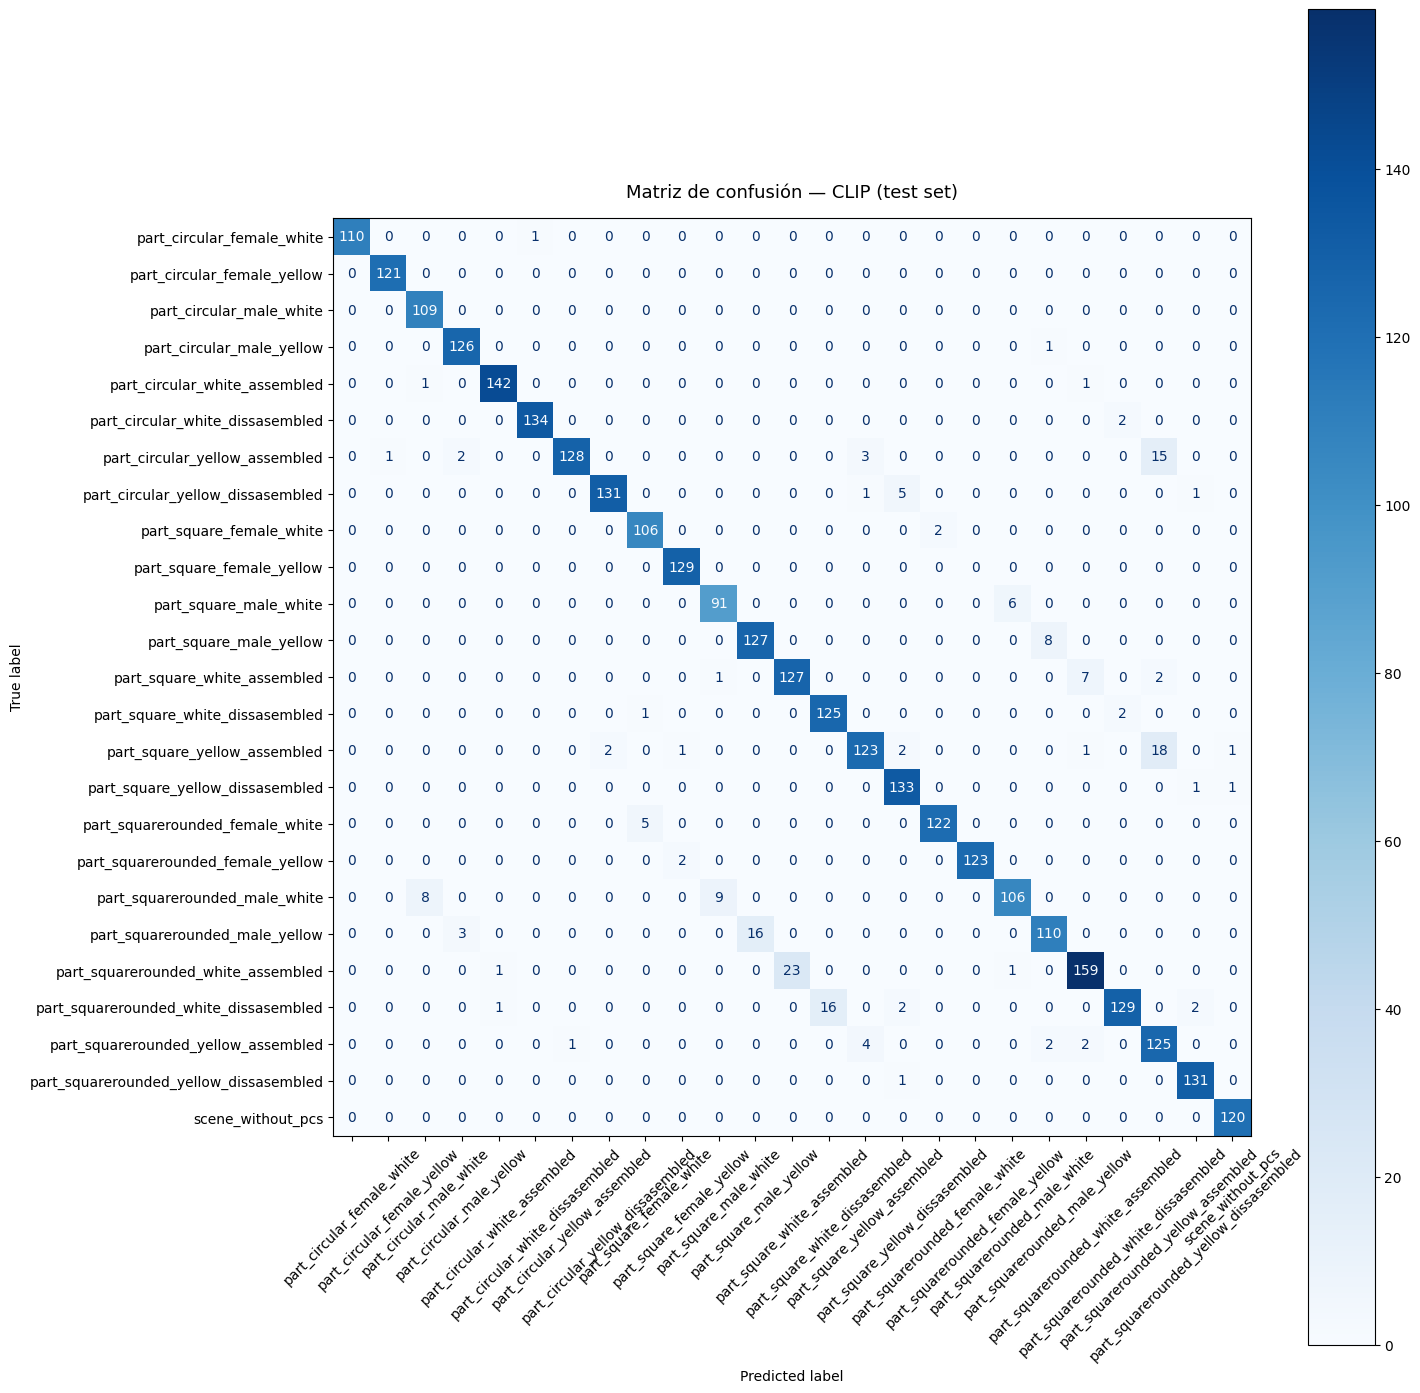

 Guardada: confusion_matrix_test.png


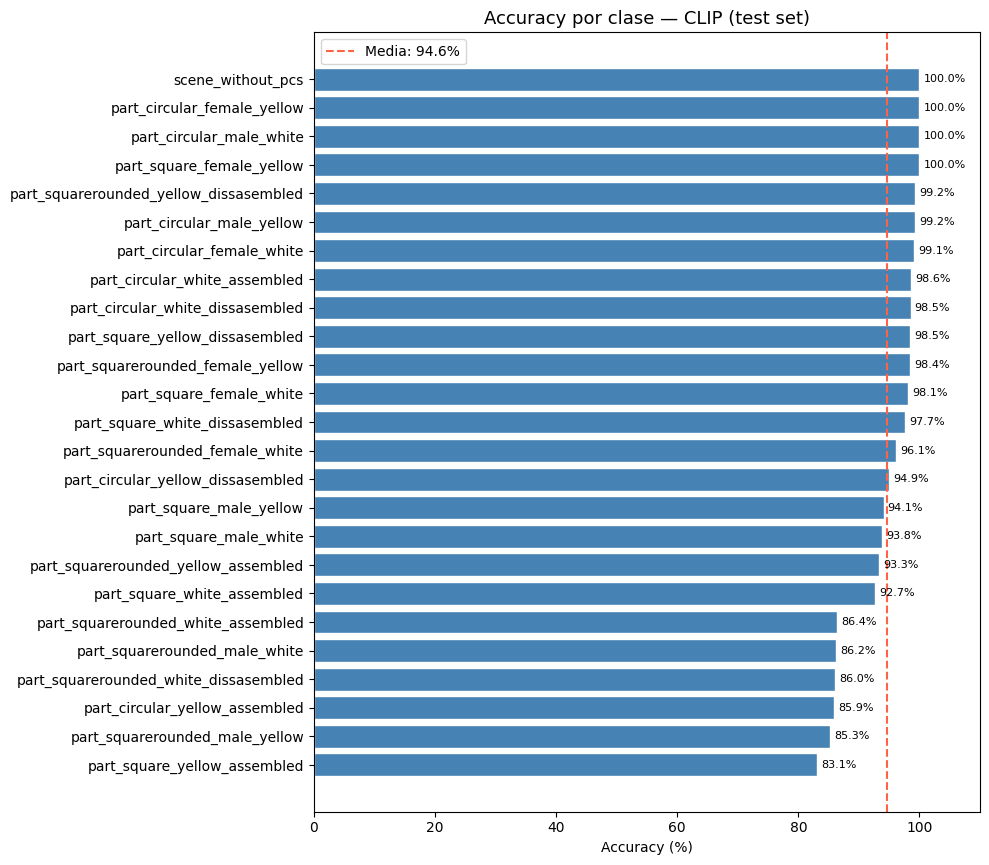

Guardada: accuracy_por_clase_test.png


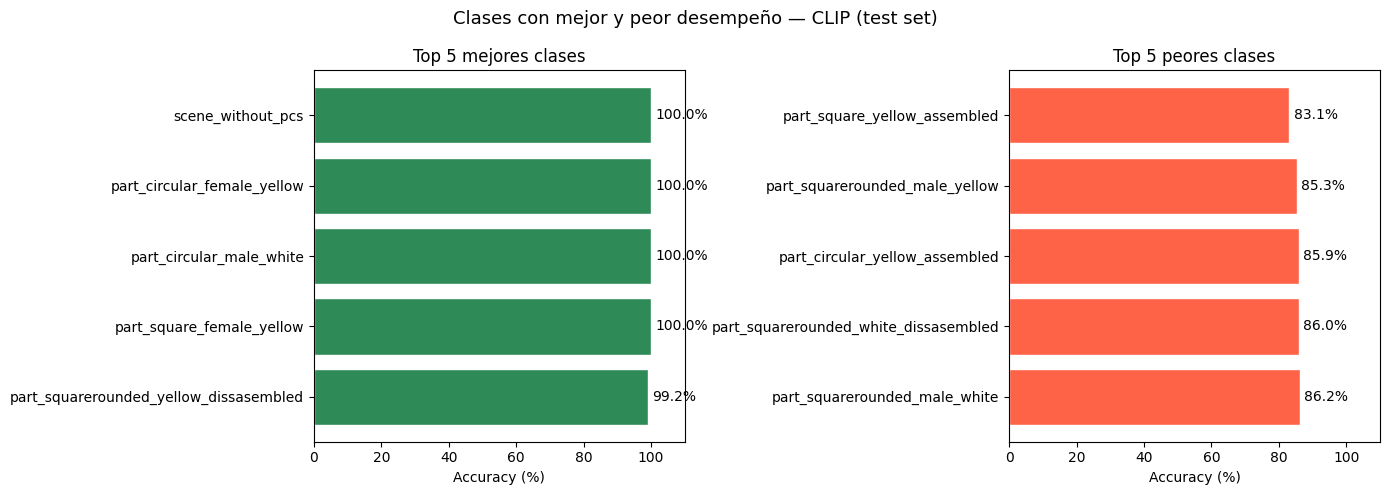

Guardada: top_bottom_clases_test.png

  Accuracy global en test: 94.23%
  Total imágenes evaluadas: 3276

                                        precision    recall  f1-score   support

            part_circular_female_white      1.000     0.991     0.995       111
           part_circular_female_yellow      0.992     1.000     0.996       121
              part_circular_male_white      0.924     1.000     0.960       109
             part_circular_male_yellow      0.962     0.992     0.977       127
         part_circular_white_assembled      0.986     0.986     0.986       144
      part_circular_white_dissasembled      0.993     0.985     0.989       136
        part_circular_yellow_assembled      0.992     0.859     0.921       149
     part_circular_yellow_dissasembled      0.985     0.949     0.967       138
              part_square_female_white      0.946     0.981     0.964       108
             part_square_female_yellow      0.977     1.000     0.989       129
             

In [8]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import os, torch, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torch.cuda.amp import autocast
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import open_clip

# ── 1. Config ─────────────────────────────────────────────────────────────────
CHECKPOINT  = "/content/best_clip.pt"           # ruta a tu modelo descargado
TEST_DIR    = "/content/dataset_final/test"
BATCH_SIZE  = 64
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
ARCH        = "ViT-B-32"
PRETRAINED  = "openai"                     # base sobre la que fine-tuneaste

#2. Cargar modelo
model, _, preprocess = open_clip.create_model_and_transforms(ARCH, pretrained=PRETRAINED)
tokenizer = open_clip.get_tokenizer(ARCH)

checkpoint = torch.load(CHECKPOINT, map_location=DEVICE)

# Compatibilidad: el state_dict puede estar en distintas keys
state_dict = (
    checkpoint.get("model_state_dict") or
    checkpoint.get("state_dict") or
    checkpoint.get("model") or
    checkpoint                          # si el archivo ES el state_dict directo
)
model.load_state_dict(state_dict, strict=False)
model = model.to(DEVICE).eval()
print(f" Modelo cargado en {DEVICE}")

#3. Dataset desde subcarpetas
class FolderDataset(Dataset):
    EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    def __init__(self, root, transform):
        self.transform = transform
        self.samples   = []          # (path, class_idx)
        self.classes   = sorted(
            d.name for d in Path(root).iterdir() if d.is_dir()
        )
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        for cls in self.classes:
            cls_dir = Path(root) / cls
            for f in cls_dir.iterdir():
                if f.suffix.lower() in self.EXTENSIONS:
                    self.samples.append((str(f), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = self.transform(Image.open(path).convert("RGB"))
        return img, label

dataset     = FolderDataset(TEST_DIR, preprocess)
class_names = dataset.classes
loader      = DataLoader(dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f" {len(class_names)} clases | {len(dataset)} imágenes de test")
print("Clases:", class_names)

#4. Prompts de texto por clase

def class_to_prompt(name):
    return f"a photo of a {name.replace('_', ' ')}"

with torch.no_grad():
    text_tokens  = tokenizer([class_to_prompt(n) for n in class_names]).to(DEVICE)
    with autocast():
        text_feats = model.encode_text(text_tokens)
    text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)

#5. Inferencia
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        with autocast():
            img_feats = model.encode_image(images)
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)

        sims  = img_feats @ text_feats.T          # (B, num_classes)
        preds = sims.argmax(dim=-1).cpu().numpy()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

#6. Gráfica 1 — Matriz de confusión
def plot_confusion_matrix(labels, preds, class_names):
    cm       = confusion_matrix(labels, preds, labels=list(range(len(class_names))))
    fig_size = max(10, len(class_names) * 0.6)
    fig, ax  = plt.subplots(figsize=(fig_size, fig_size))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues", values_format="d")
    ax.set_title("Matriz de confusión — CLIP (test set)", fontsize=13, pad=15)
    plt.tight_layout()
    plt.savefig("confusion_matrix_test.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(" Guardada: confusion_matrix_test.png")
    return cm

cm = plot_confusion_matrix(all_labels, all_preds, class_names)

#7. Gráfica 2 — Accuracy por clase (barras)
def plot_per_class_accuracy(cm, class_names):
    totals    = cm.sum(axis=1)
    corrects  = np.diag(cm)
    accuracys = np.where(totals > 0, corrects / totals, 0.0)

    order = np.argsort(accuracys)          # menor → mayor
    names_sorted = [class_names[i] for i in order]
    accs_sorted  = accuracys[order]

    fig, ax = plt.subplots(figsize=(10, max(6, len(class_names) * 0.35)))
    bars = ax.barh(names_sorted, accs_sorted * 100, color="steelblue", edgecolor="white")
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax.set_xlim(0, 110)
    ax.set_xlabel("Accuracy (%)")
    ax.set_title("Accuracy por clase — CLIP (test set)", fontsize=13)
    ax.axvline(accuracys.mean() * 100, color="tomato", linestyle="--",
               label=f"Media: {accuracys.mean()*100:.1f}%")
    ax.legend()
    plt.tight_layout()
    plt.savefig("accuracy_por_clase_test.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Guardada: accuracy_por_clase_test.png")

plot_per_class_accuracy(cm, class_names)

# 8. Gráfica 3 — Top-5 mejores y peores clases
def plot_top_bottom_classes(cm, class_names, k=5):
    totals   = cm.sum(axis=1)
    corrects = np.diag(cm)
    accs     = np.where(totals > 0, corrects / totals, 0.0)

    k = min(k, len(class_names) // 2)
    top_idx = np.argsort(accs)[-k:][::-1]
    bot_idx = np.argsort(accs)[:k]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, idx, title, color in zip(
        axes,
        [top_idx, bot_idx],
        [f"Top {k} mejores clases", f"Top {k} peores clases"],
        ["seagreen", "tomato"]
    ):
        names = [class_names[i] for i in idx]
        vals  = [accs[i] * 100 for i in idx]
        bars  = ax.barh(names[::-1], vals[::-1], color=color, edgecolor="white")
        ax.bar_label(bars, fmt="%.1f%%", padding=3)
        ax.set_xlim(0, 110)
        ax.set_xlabel("Accuracy (%)")
        ax.set_title(title, fontsize=12)
    plt.suptitle("Clases con mejor y peor desempeño — CLIP (test set)", fontsize=13)
    plt.tight_layout()
    plt.savefig("top_bottom_clases_test.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Guardada: top_bottom_clases_test.png")

plot_top_bottom_classes(cm, class_names, k=5)

# ── 9. Reporte de texto ───────────────────────────────────────────────────────
overall_acc = (all_preds == all_labels).mean()
print(f"\n{'='*55}")
print(f"  Accuracy global en test: {overall_acc*100:.2f}%")
print(f"  Total imágenes evaluadas: {len(all_labels)}")
print(f"{'='*55}\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

/tmp/ipykernel_1165/1539915624.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


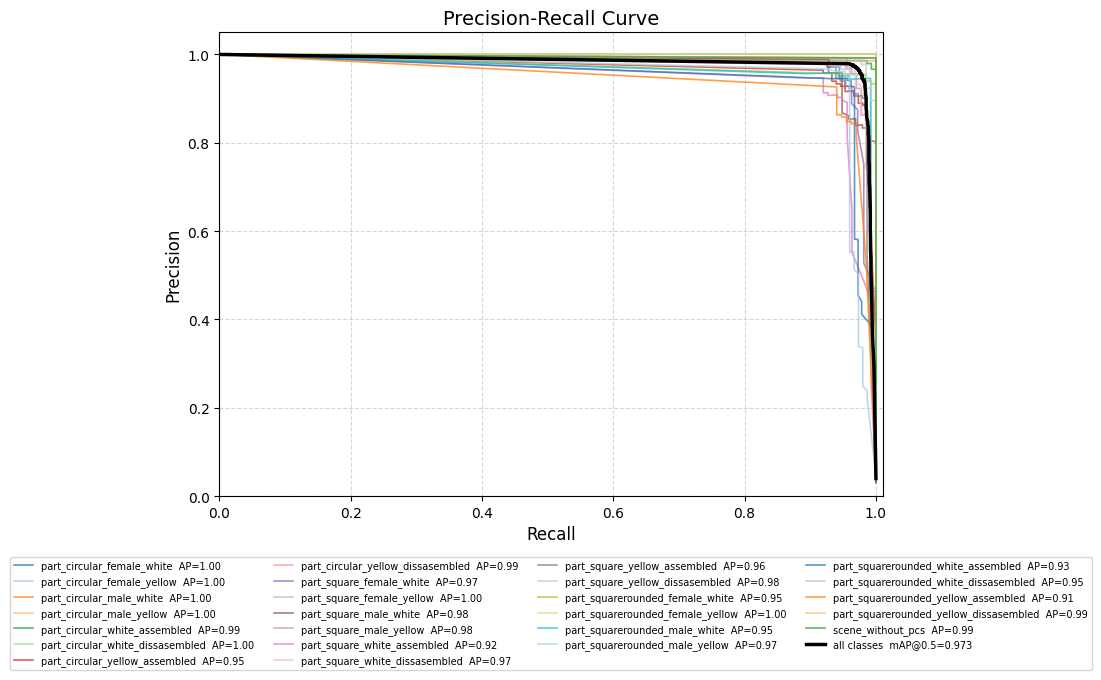

Guardada: PR_curve_test.png

  mAP (macro): 97.32%


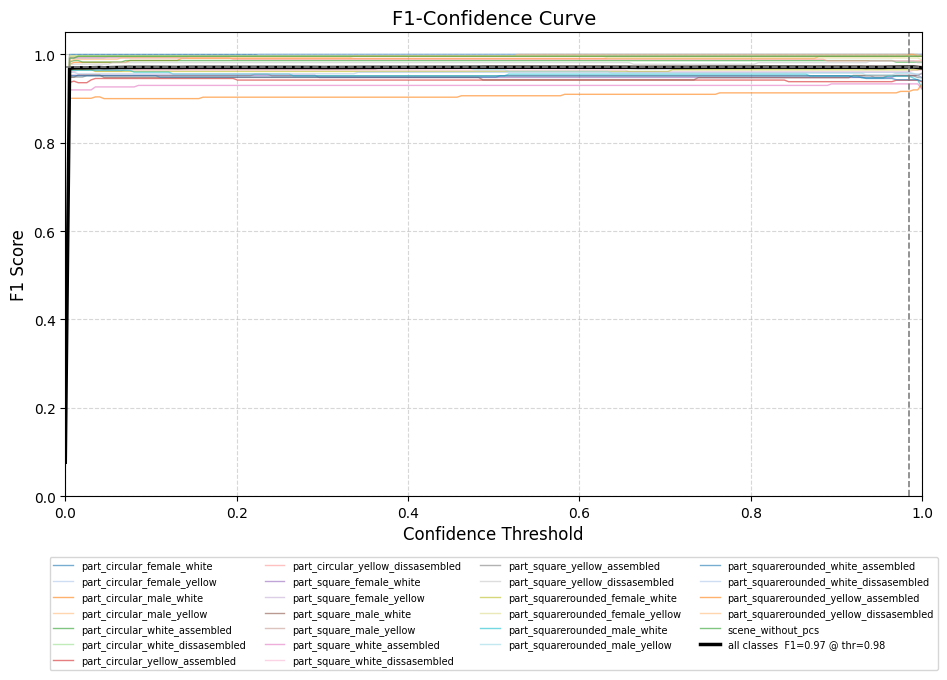

💾 Guardada: F1_curve_test.png
  Mejor threshold global: 0.985  →  F1=0.971


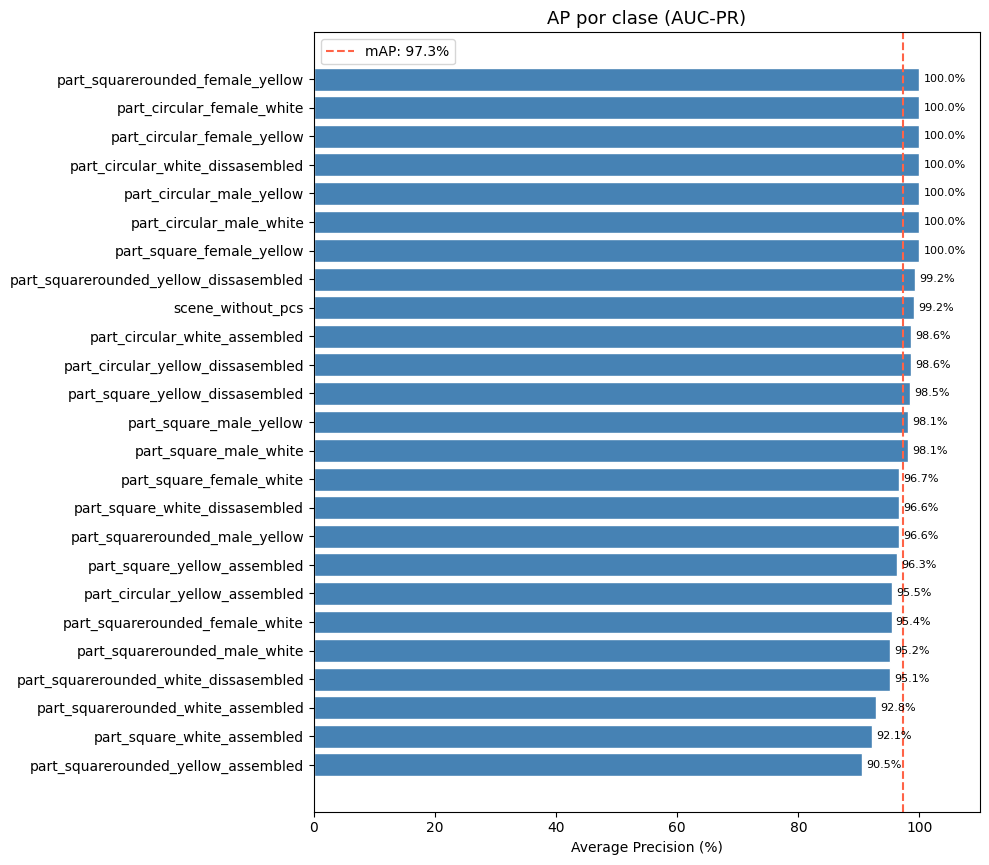

💾 Guardada: AP_por_clase_test.png


In [ ]:
#10. Scores de confianza


from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.cm as cm_module

all_scores  = []   # (N, num_classes) — probabilidades softmax
all_labels2 = []

model.eval()
with torch.no_grad():
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        with autocast():
            img_feats = model.encode_image(images)
        img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)

        sims   = img_feats @ text_feats.T
        probs  = torch.softmax(sims * 100, dim=-1)
        all_scores.append(probs.cpu().numpy())
        all_labels2.extend(labels.numpy().tolist())

all_scores  = np.vstack(all_scores)
all_labels2 = np.array(all_labels2)
n_classes   = len(class_names)

# Binarizar etiquetas: (N, C) one-hot
Y_bin = label_binarize(all_labels2, classes=list(range(n_classes)))

# 11. Gráfica — Curva PR por clase
def plot_pr_curve(Y_bin, scores, class_names):
    fig, ax = plt.subplots(figsize=(10, 7))
    colors  = cm_module.tab20.colors

    ap_per_class = []

    for i, name in enumerate(class_names):
        if Y_bin[:, i].sum() == 0:          # clase sin muestras en test
            continue
        prec, rec, _ = precision_recall_curve(Y_bin[:, i], scores[:, i])
        ap           = average_precision_score(Y_bin[:, i], scores[:, i])
        ap_per_class.append(ap)
        color = colors[i % len(colors)]
        ax.plot(rec, prec, lw=1.2, color=color, alpha=0.75, label=f"{name}  AP={ap:.2f}")

    mAP = np.mean(ap_per_class)

    # Línea "all classes" en negrita (promedio macro)
    prec_all, rec_all, _ = precision_recall_curve(
        Y_bin.ravel(), scores.ravel()
    )
    ax.plot(rec_all, prec_all, "k-", lw=2.5, label=f"all classes  mAP@0.5={mAP:.3f}")

    ax.set_xlabel("Recall",    fontsize=12)
    ax.set_ylabel("Precision", fontsize=12)
    ax.set_title("Precision-Recall Curve", fontsize=14)
    ax.set_xlim(0, 1.01)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.5)

    # Leyenda fuera del plot
    if n_classes <= 20:
        ax.legend(loc="lower left", fontsize=7.5, ncol=2)
    else:
        ax.legend(
            loc="upper center", bbox_to_anchor=(0.5, -0.12),
            fontsize=7, ncol=4, frameon=True
        )

    plt.tight_layout()
    plt.savefig("PR_curve_test.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Guardada: PR_curve_test.png")
    print(f"\n  mAP (macro): {mAP*100:.2f}%")
    return ap_per_class

ap_scores = plot_pr_curve(Y_bin, all_scores, class_names)

# 12. Gráfica — F1 vs Threshold (estilo YOLO)
def plot_f1_threshold(Y_bin, scores, class_names):
    thresholds = np.linspace(0, 1, 200)
    colors     = cm_module.tab20.colors

    fig, ax = plt.subplots(figsize=(10, 7))

    f1_matrix = np.zeros((len(class_names), len(thresholds)))

    for i, name in enumerate(class_names):
        if Y_bin[:, i].sum() == 0:
            continue
        for j, thr in enumerate(thresholds):
            preds_bin = (scores[:, i] >= thr).astype(int)
            tp = ((preds_bin == 1) & (Y_bin[:, i] == 1)).sum()
            fp = ((preds_bin == 1) & (Y_bin[:, i] == 0)).sum()
            fn = ((preds_bin == 0) & (Y_bin[:, i] == 1)).sum()
            prec = tp / (tp + fp + 1e-9)
            rec  = tp / (tp + fn + 1e-9)
            f1_matrix[i, j] = 2 * prec * rec / (prec + rec + 1e-9)

        ax.plot(thresholds, f1_matrix[i], lw=1, color=colors[i % len(colors)],
                alpha=0.6, label=name)

    # Curva F1 media (todas las clases)
    mean_f1   = f1_matrix.mean(axis=0)
    best_idx  = mean_f1.argmax()
    best_thr  = thresholds[best_idx]
    best_f1   = mean_f1[best_idx]

    ax.plot(thresholds, mean_f1, "k-", lw=2.5,
            label=f"all classes  F1={best_f1:.2f} @ thr={best_thr:.2f}")
    ax.axvline(best_thr, color="gray", linestyle="--", lw=1.2)
    ax.axhline(best_f1,  color="gray", linestyle="--", lw=1.2)

    ax.set_xlabel("Confidence Threshold", fontsize=12)
    ax.set_ylabel("F1 Score",             fontsize=12)
    ax.set_title("F1-Confidence Curve",   fontsize=14)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle="--", alpha=0.5)

    if n_classes <= 20:
        ax.legend(loc="lower center", fontsize=7.5, ncol=2)
    else:
        ax.legend(
            loc="upper center", bbox_to_anchor=(0.5, -0.12),
            fontsize=7, ncol=4, frameon=True
        )

    plt.tight_layout()
    plt.savefig("F1_curve_test.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Guardada: F1_curve_test.png")
    print(f"  Mejor threshold global: {best_thr:.3f}  →  F1={best_f1:.3f}")

plot_f1_threshold(Y_bin, all_scores, class_names)

#13. Gráfica — AP por clase
def plot_ap_bars(ap_scores, class_names):
    order  = np.argsort(ap_scores)
    names  = [class_names[i] for i in order]
    values = [ap_scores[i]   for i in order]

    fig, ax = plt.subplots(figsize=(10, max(6, len(class_names) * 0.35)))
    bars = ax.barh(names, [v * 100 for v in values], color="steelblue", edgecolor="white")
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8)
    ax.axvline(np.mean(ap_scores) * 100, color="tomato", linestyle="--",
               label=f"mAP: {np.mean(ap_scores)*100:.1f}%")
    ax.set_xlim(0, 110)
    ax.set_xlabel("Average Precision (%)")
    ax.set_title("AP por clase (AUC-PR)", fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.savefig("AP_por_clase_test.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Guardada: AP_por_clase_test.png")

plot_ap_bars(ap_scores, class_names)

## Descargar gráficas organizadas

In [ ]:
import os
import shutil
from google.colab import files

# --- 1. Crear directorios para organizar las gráficas ---
output_dir = "./output_graphs"
os.makedirs(output_dir, exist_ok=True)

train_dir = os.path.join(output_dir, "training_results")
val_dir = os.path.join(output_dir, "validation_results")
test_dir = os.path.join(output_dir, "test_results")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print("Directorios creados.")

# --- 2. Mover archivos a sus respectivos directorios ---

# Gráficas de entrenamiento
shutil.move("training_curves.png", train_dir)

# Gráficas de validación
shutil.move("confusion_matrix.png", val_dir)

# Gráficas de test
shutil.move("confusion_matrix_test.png", test_dir)
shutil.move("accuracy_por_clase_test.png", test_dir)
shutil.move("top_bottom_clases_test.png", test_dir)
shutil.move("PR_curve_test.png", test_dir)
shutil.move("F1_curve_test.png", test_dir)
shutil.move("AP_por_clase_test.png", test_dir)

print("Archivos movidos a sus carpetas.")

# --- 3. Comprimir cada directorio ---
shutil.make_archive(train_dir, 'zip', train_dir)
shutil.make_archive(val_dir, 'zip', val_dir)
shutil.make_archive(test_dir, 'zip', test_dir)

print("Carpetas comprimidas.")

# --- 4. Descargar los archivos ZIP ---
print("Descargando archivos ZIP:")
files.download(f"{train_dir}.zip")
files.download(f"{val_dir}.zip")
files.download(f"{test_dir}.zip")

print("¡Descarga completada!")


Directorios creados.
Archivos movidos a sus carpetas.
Carpetas comprimidas.
Descargando archivos ZIP:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

¡Descarga completada!


probar el modelo con una imagen de test

In [ ]:
import torch.nn.functional as F
from PIL import Image

# ==========================================
# 0. CAMBIA ESTA RUTA POR LA QUE QUIERAS PROBAR
# ==========================================
ruta_nueva = "/content/dataset_final/test/piezas_soldadas/sd_seg_1779809910s_png.rf.a1357f7a5bf588d5c389580873f063d3.jpg"
# ==========================================

# Cargamos la nueva imagen físicamente
image_test = preprocess(Image.open(ruta_nueva)).unsqueeze(0)

# 1. Asegurar que todo esté en el mismo dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
image_test = image_test.to(device) # Usamos la nueva imagen

# Tokenizar los nombres de las clases para las descripciones de texto
text_descriptions = [f"a photo of a {class_name.replace('_', ' ')}" for class_name in class_names]
text = tokenizer(text_descriptions).to(device)

model.eval()

with torch.no_grad():
    # 2. Extraer características
    image_features = model.encode_image(image_test) # Usamos image_test
    text_features = model.encode_text(text)

    # 3. Normalizar
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # 4. Calcular similitud
    logit_scale = model.logit_scale.exp()
    logits_per_image = logit_scale * image_features @ text_features.T
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

# 5. Mostrar resultados
print("-" * 30)
print(f"IMAGEN: {ruta_nueva.split('/')[-1]}")
print("-" * 30)

for i, class_name in enumerate(class_names):
    confianza = probs[i] * 100
    print(f"{class_name:25} : {confianza:>6.2f}%")

top_idx = probs.argmax()
print("-" * 30)
print(f"PREDICCIÓN FINAL: {class_names[top_idx].upper()}")
print("-" * 30)

descargar el modelo .zip

In [ ]:
import torch

# Define la ruta y el nombre del archivo donde guardarás los pesos del modelo
model_save_path = "clip_model_weights_v2.pt"

# Guarda el estado del modelo
torch.save(model.state_dict(), model_save_path)

print(f"Modelo guardado en {model_save_path}")

In [ ]:
import zipfile
import os
from google.colab import files

# Nombre del archivo de los pesos del modelo
model_filename = "clip_model_weights_v2.pt"
# Nombre del archivo ZIP a crear
zip_filename = "clip_model_v2.zip"

# Crear el archivo ZIP
with zipfile.ZipFile(zip_filename, 'w') as zf:
    zf.write(model_filename, os.path.basename(model_filename))

print(f"'{model_filename}'guardado'{zip_filename}'.")

# Opcional: Descargar el archivo ZIP automáticamente
files.download(zip_filename)